# AI 500 PA3

*__Submission Instructions:__*
- Rename this notebook to `PA3_rollnumber.ipynb` before submission on LMS.
- The output of all cells must be present in the version of the notebook you submit.

In [26]:
rollnumber = 24280026

SEED = 8 # DO NOT CHANGE THIS

In [27]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
%matplotlib notebook
%matplotlib inline

## Task 1 - Neural Network

Recommended Watch: https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi

This playlist will help build a really solid intuitive understanding of how (and why) neural networks work.

#### Instructions:
In this task, you will be implementing a neural network from scratch using numpy. The skeleton of the neural network class is provided to you. You only need to write the parts that are incomplete/empty.

*Forward/backward pass & Weight Update:* Implement the forward and backward pass algorithms. Try to vectorize your code as much as possible, relying on numpy functions instead of for loops.

*Optimizers:*
Full-batch Gradient Descent has been implemented for you. You need to implement minibatch and stochastic gradient descent variants.

For weights we will use standard normal distribution (0 mean and 1 var).
Biases will be initialized to all zero.

**Visualization code** is provided to plot the learnt decision boundary of your model.


*Activation Functions:* You will implement the following activation functions (note that forward and backward pass will need to be adjusted according to the choice of the activation function):
- Sigmoid
- ReLU
- Leaky ReLU (leaky slope is fixed at 0.05)


In [28]:
# Helper function to plot a decision boundary. You don't need to understand this.

def plot_decision_boundary(pred_func, x_min, x_max, y_min, y_max, cmap, ax):
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the function value for the whole gid
    Z = pred_func(np.c_[xx.flatten(), yy.flatten()])
    Z = Z.reshape(xx.shape)
    # Plot the contour
    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.5)

In [48]:
class NeuralNetwork():
    @staticmethod
    def cross_entropy_loss(y_pred, y_true):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.sum(y_true * np.log(y_pred)) / y_pred.shape[0]
        return loss

    @staticmethod
    def mean_squared_loss(y_pred, y_true):
        loss_error = np.square(y_pred - y_true)
        mean_squared_loss	= np.mean(loss_error)
        return mean_squared_loss


    @staticmethod
    def accuracy(y_pred, y_true):
        correct = np.sum(y_pred == y_true)
        total= len(y_true)
        accuracy= correct / total
        return accuracy

    @staticmethod
    def softmax(x):
        exps = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exps / np.sum(exps, axis=1, keepdims=True)

    @staticmethod
    def sigmoid(x):
        sigmoid= 1 / (1 + np.exp(-x))
        return sigmoid

    @staticmethod
    def ReLU(x):
        return np.maximum(0, x)

    def Leaky_ReLU(self, x):
        return np.where(x > 0, x, self.leaky_slope * x)

    def __init__(self, nodes_per_layer: list[int], mode: str = 'classification', optimizer: str = 'fullbatch', activation: str = 'sigmoid', batch_size: int = 64):
        '''Creates a Feed-Forward Neural Network.
        "nodes_per_layer" is a list containing the number of nodes in each layer (including the input layer) e.g. [2, 10, 10, 2] (2 features, 2 hidden layers with 10 neurons each, 2 classes)"
        '''

        if len(nodes_per_layer) < 2:
            raise ValueError('Network must have at least 2 layers (input and output).')
        if not (np.array(nodes_per_layer) > 0).all():
            raise ValueError('The number of nodes in all layers must be positive.')

        assert mode.lower() in ['classification', 'regression'], "Only classification and regression modes are supported"
        assert optimizer.lower() in ['sgd', 'minibatch', 'fullbatch'], 'Unknown Optimizer'
        assert activation.lower() in ['sigmoid', 'relu', 'leaky_relu'], 'Unknown activation function'

        self.num_layers = None
        self.mode = mode
        self.nodes_per_layer = nodes_per_layer
        self.input_shape = None
        self.output_shape = None
        self.optimizer = optimizer
        self.activation_strat = activation
        self.batch_size = batch_size

        if activation == 'leaky_relu':
            self.leaky_slope = 0.05

        # Initialize all weights based on a standard normal distribution and all biases to 0.
        self.weights_ = []
        self.biases_ = []
        self.__init_weights(nodes_per_layer)

    def __init_weights(self, nodes_per_layer):
      np.random.seed(42)  # Set seed for reproducibility
      for i in range(1, len(nodes_per_layer)):
          weight_matrix = np.random.normal(size=(nodes_per_layer[i - 1], nodes_per_layer[i]))
          self.weights_.append(weight_matrix)
          bias_vector = np.zeros((1, nodes_per_layer[i]))
          self.biases_.append(bias_vector)



    def fit(self, Xs, Ys, X_val, Y_val, epochs, lr=1e-3):
        self.history = []
        self.val_history = []

        # One-hot encode targets for classification
        if self.mode == 'classification':
            num_classes = self.nodes_per_layer[-1]
            Ys = np.eye(num_classes)[Ys]
            Y_val = np.eye(num_classes)[Y_val]

        self._run_optimizer(Xs, Ys, X_val, Y_val, epochs, lr)
        return self.history, self.val_history


    def _run_optimizer(self, Xs, Ys, X_val, Y_val, epochs, lr):
        ''' Executes the gradient descent algorithm '''

        if self.optimizer == 'fullbatch':
            for epoch in tqdm(range(epochs)):
                activations = self.forward_pass(Xs) # Forward Pass over whole dataset
                deltas = self.backward_pass(Ys, activations) # Backward pass takes layer activations and true labels as input

                layer_inputs = [Xs] + activations[:-1]
                self.weight_update(deltas, layer_inputs, lr) # Weight update

                preds = self.predict(Xs) # Make prediction on input sample
                current_loss = self.cross_entropy_loss(preds, Ys) if self.mode == 'classification' else self.mean_squared_loss(preds, Ys)
                self.history.append(current_loss)

                # Compute Validation Loss at the end of each epoch
                preds = self.predict(X_val)
                current_loss = self.cross_entropy_loss(preds, Y_val) if self.mode == 'classification' else self.mean_squared_loss(preds, Y_val)
                self.val_history.append(current_loss)


        elif self.optimizer == 'sgd':
            for epoch in tqdm(range(epochs)):
                      for i in range(Xs.shape[0]):  # Looping  each sample
                          x_sample = Xs[i:i+1]
                          y_sample = Ys[i:i+1]

                          activations = self.forward_pass(x_sample)  # for one sample
                          deltas = self.backward_pass(y_sample, activations)

                          layer_inputs = [x_sample] + activations[:-1]
                          self.weight_update(deltas, layer_inputs, lr)  # Updating weights and biases here

                      preds = self.predict(Xs)
                      current_loss = self.cross_entropy_loss(preds, Ys) if self.mode == 'classification' else self.mean_squared_loss(preds, Ys)
                      self.history.append(current_loss)

                      preds = self.predict(X_val)
                      current_loss = self.cross_entropy_loss(preds, Y_val) if self.mode == 'classification' else self.mean_squared_loss(preds, Y_val)
                      self.val_history.append(current_loss)


        elif self.optimizer == 'minibatch':
              for epoch in tqdm(range(epochs)):
                for start in range(0, Xs.shape[0], self.batch_size):  # Looping in mini-batches
                    end = start + self.batch_size
                    x_batch = Xs[start:end]
                    y_batch = Ys[start:end]

                    activations = self.forward_pass(x_batch)  #  for  batch
                    deltas = self.backward_pass(y_batch, activations)  #  for  batch

                    layer_inputs = [x_batch] + activations[:-1]
                    self.weight_update(deltas, layer_inputs, lr)

                preds = self.predict(Xs)
                current_loss = self.cross_entropy_loss(preds, Ys) if self.mode == 'classification' else self.mean_squared_loss(preds, Ys)
                self.history.append(current_loss)

                preds = self.predict(X_val)
                current_loss = self.cross_entropy_loss(preds, Y_val) if self.mode == 'classification' else self.mean_squared_loss(preds, Y_val)
                self.val_history.append(current_loss)


    def forward_pass(self, input_data):
        """
        Execute feed-forward algorithm
        Supports different activation functions
        """
        if input_data.ndim == 1:
            input_data = input_data.reshape(1, -1)

        activations = []
        layer_input = input_data

        for i in range(len(self.weights_)):

            z = np.dot(layer_input, self.weights_[i]) + self.biases_[i]

            if i == len(self.weights_) - 1 and self.mode == 'classification':
                layer_output = self.softmax(z)
            else:
                if self.activation_strat == 'sigmoid':
                    layer_output = self.sigmoid(z)
                elif self.activation_strat == 'relu':
                    layer_output = self.ReLU(z)
                elif self.activation_strat == 'leaky_relu':
                    layer_output = self.Leaky_ReLU(z)
                else:
                    raise ValueError(f"Unknown activation strategy: {self.activation_strat}")

            activations.append(layer_output)
            layer_input = layer_output

        return activations

    def backward_pass(self, targets, layer_activations):
      deltas = []
      last_delta = None

      # Output layer delta
      if self.mode == 'classification':
          last_delta = layer_activations[-1] - targets
      elif self.mode == 'regression':
          last_delta = 2 * (layer_activations[-1] - targets) / targets.shape[0]

      deltas.append(last_delta)

      # Backpropagate  layers
      for i in range(len(self.weights_) - 1, 0, -1):
          # print(f"Backward Layer {i}:")
          # print(f"Last Delta shape: {last_delta.shape}")
          # print(f"Weight shape: {self.weights_[i].shape}")
          # print(f"Layer activation shape: {layer_activations[i - 1].shape}")  # Use i-1 for current layer activations

          # Calculate delta for the current layer
          delta = np.dot(last_delta, self.weights_[i].T)

          # Apply activation derivative using the correct layer's activations
          if self.activation_strat == 'sigmoid':
              activation_derivative = layer_activations[i - 1] * (1 - layer_activations[i - 1])
          elif self.activation_strat == 'relu':
              activation_derivative = (layer_activations[i - 1] > 0).astype(float)
          elif self.activation_strat == 'leaky_relu':
              activation_derivative = np.where(layer_activations[i - 1] > 0, 1, self.leaky_slope)


          if activation_derivative.shape != delta.shape:
              raise ValueError(f"Activation derivative shape {activation_derivative.shape} does not match delta shape {delta.shape}.")

          delta *= activation_derivative
          deltas.append(delta)
          last_delta = delta

      deltas.reverse()
      return deltas

    def weight_update(self, deltas, layer_inputs, lr):
          for i in range(len(self.weights_)):
              # print(f"Layer {i}:")
              # print(f"Weight shape: {self.weights_[i].shape}")
              # print(f"Input shape: {layer_inputs[i].shape}")
              # print(f"Delta shape: {deltas[i].shape}")

              #  gradient for weights
              gradient = np.dot(layer_inputs[i].T, deltas[i])
              self.weights_[i] -= lr * gradient

              #  gradient for biases and update
              bias_gradient = np.mean(deltas[i], axis=0)
              self.biases_[i] -= lr * bias_gradient

    def predict(self, Xs):
        '''Returns the model predictions (output of the last layer) for the given "Xs".'''
        return self.forward_pass(Xs)[-1]

    def evaluate(self, Xs, Ys):
        '''Returns appropriate metrics for the task, calculated on the dataset passed to this method.'''
        pred = self.predict(Xs)
        if self.mode == 'regression':
            return self.mean_squared_loss(pred, Ys)
        elif self.mode == 'classification':
            return self.cross_entropy_loss(pred, Ys), self.accuracy(pred.argmax(axis=1), Ys.argmax(axis=1))

Generating a moons dataset for binary classification:

[Text(0.5, 0, 'Feature 1'), Text(0, 0.5, 'Feature 2')]

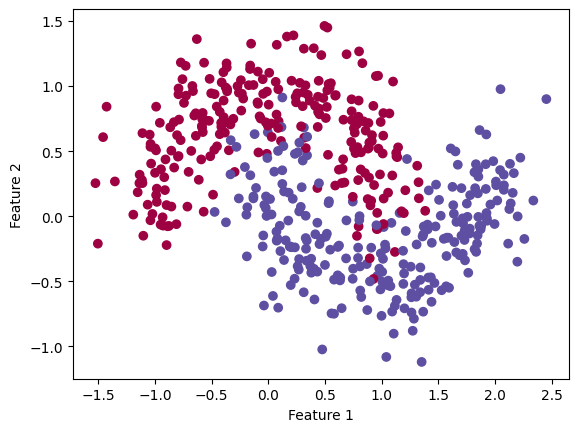

In [5]:
data_x, data_y = make_moons(500, noise=0.25, random_state=SEED)
plt.scatter(data_x[:,0], data_x[:,1], c=data_y, cmap=plt.cm.Spectral)
plt.gca().set(xlabel='Feature 1', ylabel='Feature 2')

Doing an 80-20 train-test split

In [30]:
X_train, X_val, Y_train, Y_val = train_test_split(data_x, data_y, test_size = 0.2, random_state=SEED)

### Classification task + Plotting the loss curves
- To check your implementation efficiency, we will check the running time of your code.<br>
- The secret to improving your efficency: __Vectorize__

### Your running time will be graded.

In [31]:
import time

def plot_losses(train_hist, val_hist):

    '========================'
    # Code here



    plt.figure(figsize=(10, 6))

    # Plot training loss
    plt.plot(train_hist, label='Training Loss', linestyle='-', marker='o')

    plt.plot(val_hist, label='Validation Loss', linestyle='--', marker='x')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss for Epochs')
    plt.legend()
    plt.grid(True)

    # Show plot

    '========================'
    plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
Weight shape: (40, 20)
Input shape: (64, 40)
Delta shape: (64, 20)
Layer 3:
Weight shape: (20, 2)
Input shape: (64, 20)
Delta shape: (64, 2)
Layer 0:
Weight shape: (2, 60)
Input shape: (64, 2)
Delta shape: (64, 60)
Layer 1:
Weight shape: (60, 40)
Input shape: (64, 60)
Delta shape: (64, 40)
Layer 2:
Weight shape: (40, 20)
Input shape: (64, 40)
Delta shape: (64, 20)
Layer 3:
Weight shape: (20, 2)
Input shape: (64, 20)
Delta shape: (64, 2)
Layer 0:
Weight shape: (2, 60)
Input shape: (64, 2)
Delta shape: (64, 60)
Layer 1:
Weight shape: (60, 40)
Input shape: (64, 60)
Delta shape: (64, 40)
Layer 2:
Weight shape: (40, 20)
Input shape: (64, 40)
Delta shape: (64, 20)
Layer 3:
Weight shape: (20, 2)
Input shape: (64, 20)
Delta shape: (64, 2)
Layer 0:
Weight shape: (2, 60)
Input shape: (64, 2)
Delta shape: (64, 60)
Layer 1:
Weight shape: (60, 40)
Input shape: (64, 60)
Delta shape: (64, 40)
Layer 2:
Weight shape: (40, 20)
Input shape: (64, 40)
Delt

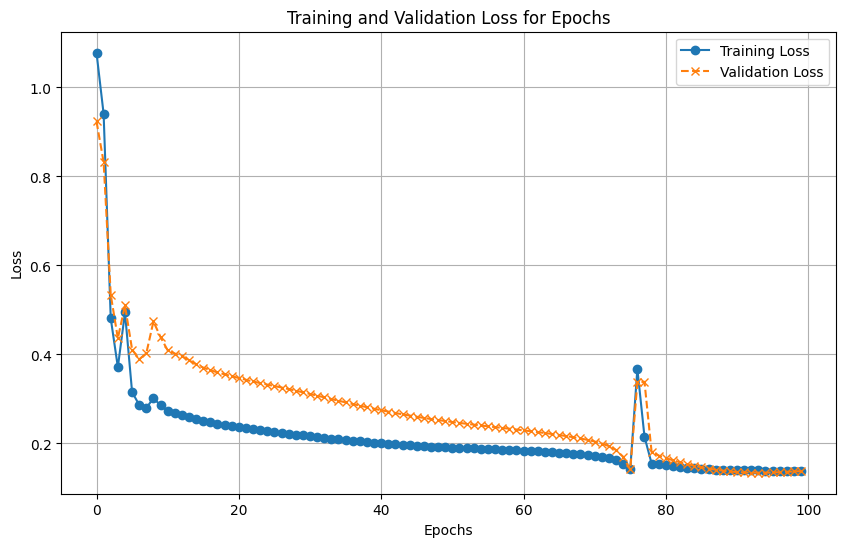

In [8]:

# PLEASE DO NOT CHANGE THE INPUT AND OUTPUT SIZE OR THE MODE OR ANYTHING
# FOR YOUR SAKE AND OURS
nn = NeuralNetwork([2, 60, 40, 20, 2], mode='classification', activation='sigmoid', optimizer = 'minibatch', batch_size=64)
start = time.time()
history, val_hist = nn.fit(X_train, Y_train, X_val, Y_val, epochs = 100, lr = 0.01)

# end time
end = time.time()
print("Runtime of the algorithm is ",round((end - start),3)," seconds")

# Plot both training and val loss history
plot_losses(history, val_hist)

In [32]:
# network_size_2 = [2, 20, 30, 10, 2]  # Modified network size
# total_params_2 = calculate_parameters(network_size_2)  # Total Parameters: 842
# print(f"Experiment 2 - Total Parameters: {total_params_2}")

# nn_2 = NeuralNetwork(network_size_2, mode='classification', activation='sigmoid', optimizer='fullbatch', batch_size=32)
# history_2, val_hist_2 = nn_2.fit(X_train, Y_train_encoded, X_val, Y_val_encoded, epochs=80, lr=0.01)

# # Plot both training and validation loss history
# plot_losses(history_2, val_hist_2)

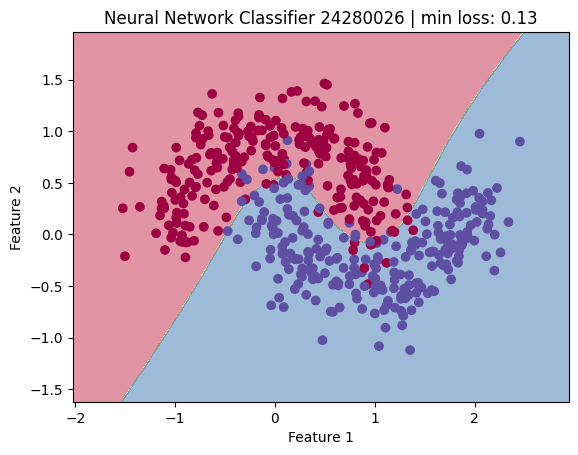

In [10]:
fig, ax = plt.subplots()
x_min, x_max = data_x[:, 0].min() - .5, data_x[:, 0].max() + .5
y_min, y_max = data_x[:, 1].min() - .5, data_x[:, 1].max() + .5
plot_decision_boundary(lambda x: nn.predict(x).argmax(axis=1),
                       x_min, x_max, y_min, y_max,
                       plt.cm.Spectral, ax)
ax.scatter(data_x[:,0], data_x[:,1], c=data_y, cmap=plt.cm.Spectral)
ax.set(xlabel='Feature 1', ylabel='Feature 2', title=f'Neural Network Classifier {rollnumber} | min loss: {np.min(val_hist):.2f}')
plt.show()

## Task 2 - Experimentation

Experiment with different network sizes, activation functions, learning rates, epochs, and optimizers, and comment on which weight activation function + optimizer yield the best results. Go crazy!

*Note*: Add at least 5 experiments with various nodes per layer and number of layers in the notebook, and calculate the total number of parameters for each of your models. Add those as a comment next to your `network_size` declaration

# **In the experiments below, I observed The most effective combination is Leaky ReLU + Mini-Batch Optimiser, which balances computational efficiency with  and results in the curves are better than orhers.**


In [33]:
# network_size = []
# nn = NeuralNetwork(network_size,)
# history, val_hist = nn.fit(X_train, pd.get_dummies(Y_train).values, X_val, pd.get_dummies(Y_val).values, epochs=1000, lr= 0.01)

# plot_losses(history, val_hist)


In [34]:
def calculate_parameters(layers):  #caclculating layers by dimesnions
    params = 0
    for i in range(1, len(layers)):
        params += layers[i - 1] * layers[i] + layers[i]
    return params


Experiment 1 - Total Parameters: 482


  0%|          | 0/500 [00:00<?, ?it/s]

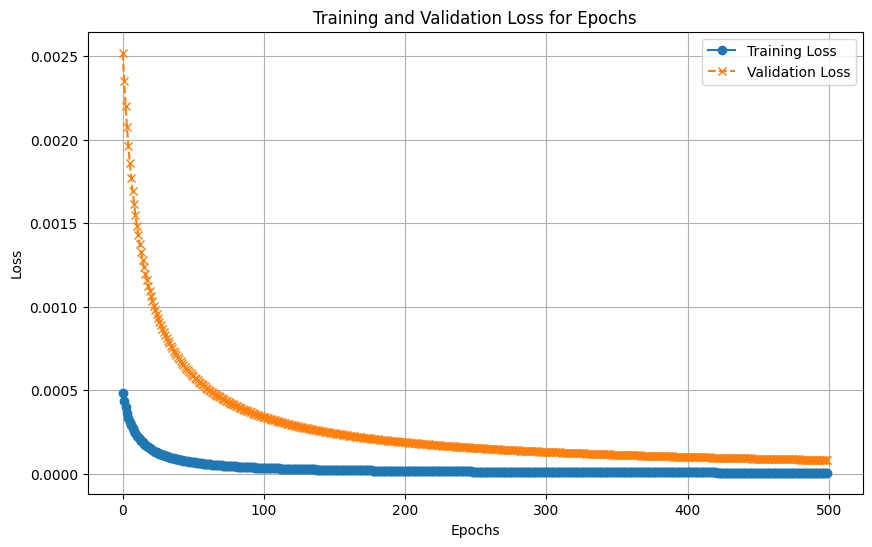

In [66]:
# Experiment 1
network_size = [2, 10, 20, 10, 2]  # Total Parameters Calculation
total_params = calculate_parameters(network_size)  # Total Parameters: 482
print(f"Experiment 1 - Total Parameters: {total_params}")

# Ensure labels are integers (if needed)
if len(Y_train.shape) > 1:
    Y_train = np.argmax(Y_train, axis=1)
    Y_val = np.argmax(Y_val, axis=1)

# Initialize and train the neural network
nn = NeuralNetwork(network_size, mode='classification', activation='relu', optimizer='minibatch', batch_size=64)
history, val_hist = nn.fit(X_train, Y_train, X_val, Y_val, epochs=500, lr=0.01)

# Plot both training and validation loss history
plot_losses(history, val_hist)


Experiment 2 - Total Parameters: 305


  0%|          | 0/100 [00:00<?, ?it/s]

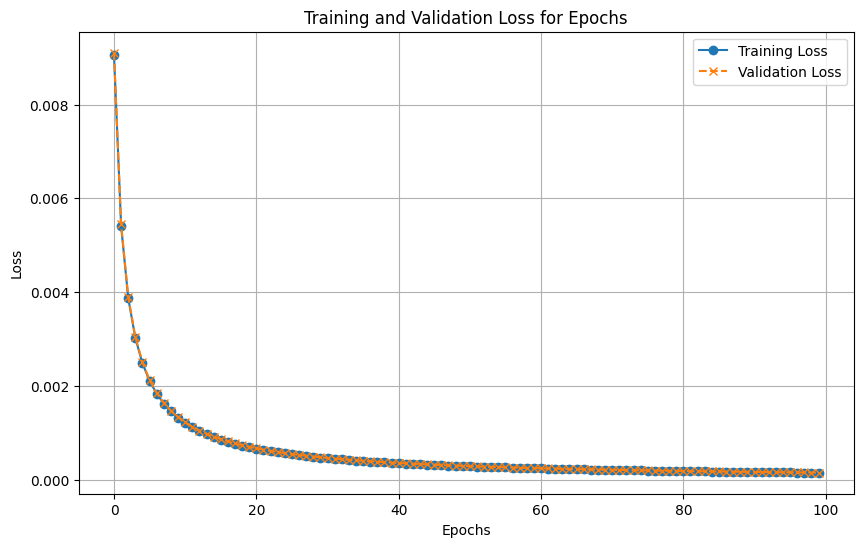

In [55]:
# Experiment 2
network_size = [2, 8, 15, 8, 2]
total_params = calculate_parameters(network_size)  # Total parameters: 305
print(f"Experiment 2 - Total Parameters: {total_params}")

# Ensure labels are integers (if needed)
if len(Y_train.shape) > 1:
    Y_train = np.argmax(Y_train, axis=1)
    Y_val = np.argmax(Y_val, axis=1)

# Initialize and train the neural network
nn = NeuralNetwork(network_size, mode='classification', activation='sigmoid', optimizer='sgd', batch_size=64)
history, val_hist = nn.fit(X_train, Y_train, X_val, Y_val, epochs=100, lr=0.01)

# Plot both training and validation loss history
plot_losses(history, val_hist)


Experiment 3 - Total Parameters: 242


  0%|          | 0/100 [00:00<?, ?it/s]

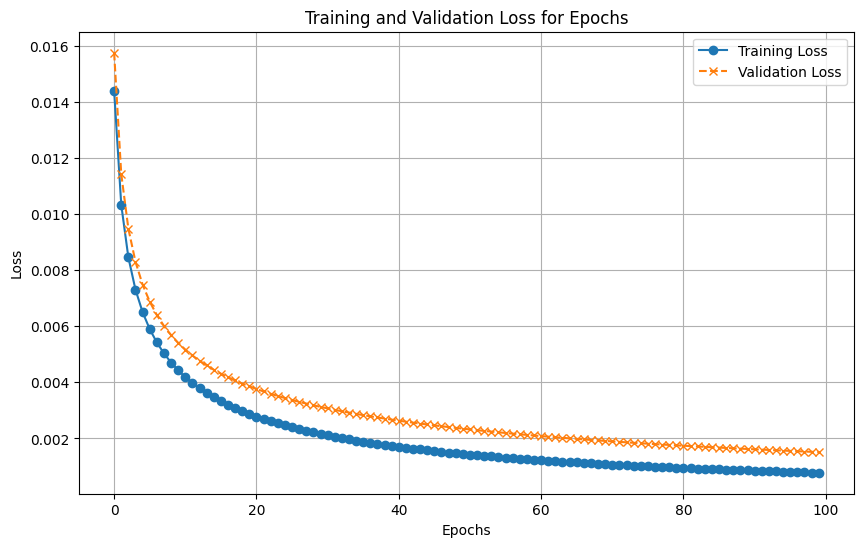

In [54]:

# Experiment 3
network_size = [2, 6,6, 20, 2]
total_params = calculate_parameters(network_size)  # Total parameters: 242
print(f"Experiment 3 - Total Parameters: {total_params}")

# Ensure labels are integers (if needed)
if len(Y_train.shape) > 1:
    Y_train = np.argmax(Y_train, axis=1)
    Y_val = np.argmax(Y_val, axis=1)

# Initialize and train the neural network
nn = NeuralNetwork(network_size, mode='classification', activation='leaky_relu', optimizer='minibatch', batch_size=64)
history, val_hist = nn.fit(X_train, Y_train, X_val, Y_val, epochs=100, lr=0.01)

# Plot both training and validation loss history
plot_losses(history, val_hist)


  0%|          | 0/100 [00:00<?, ?it/s]

Experiment 4 - Total Parameters: 305


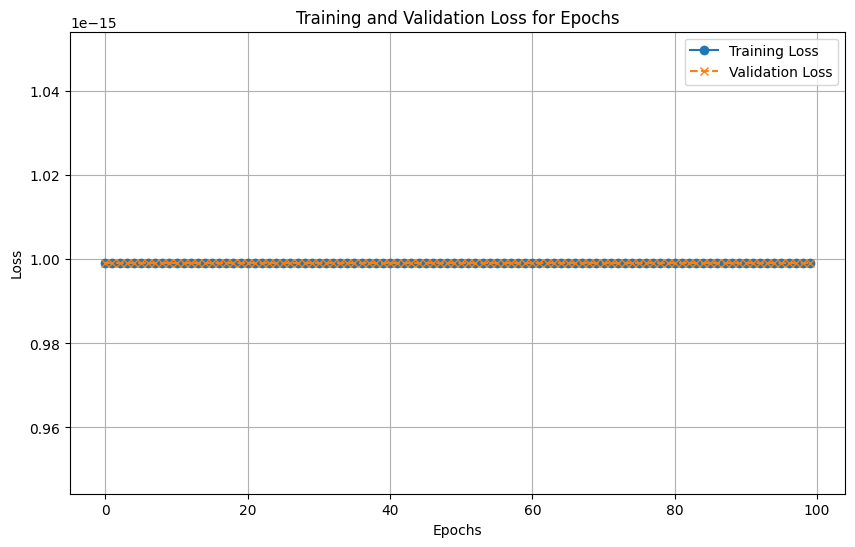

In [56]:
#Experiment 4
nn = NeuralNetwork([2, 12, 6, 20, 2], mode='classification', activation='leaky_relu', optimizer = 'fullbatch', batch_size=64)
history, val_hist = nn.fit(X_train, Y_train, X_val, Y_val, epochs = 100, lr = 0.01)

total_params = calculate_parameters(network_size)  # Total parameters: 305
print(f"Experiment 4 - Total Parameters: {total_params}")
# Plot both training and val loss history
plot_losses(history, val_hist)



  0%|          | 0/100 [00:00<?, ?it/s]

Runtime of the algorithm is  0.237  seconds


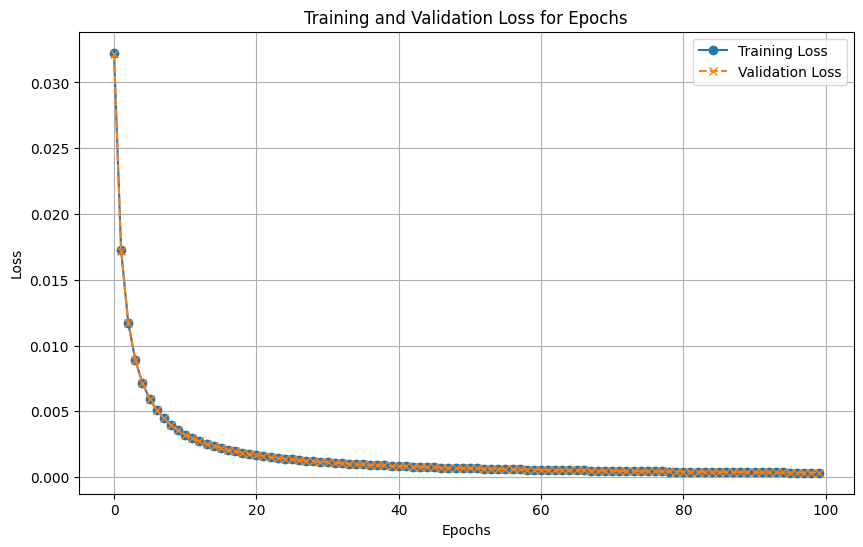

In [57]:
#Experiment 5
nn = NeuralNetwork([2, 6, 6, 10, 2], mode='classification', activation='sigmoid', optimizer = 'minibatch', batch_size=64)
start = time.time()
history, val_hist = nn.fit(X_train, Y_train, X_val, Y_val, epochs = 100, lr = 0.01)

# end time
end = time.time()
print("Runtime of the algorithm is ",round((end - start),3)," seconds")

# Plot both training and val loss history
plot_losses(history, val_hist)

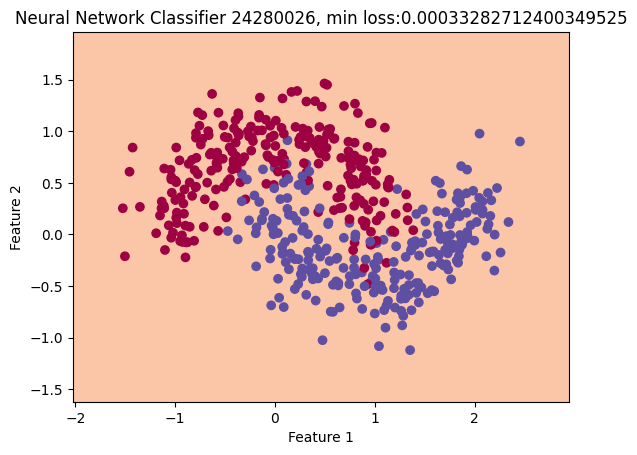

In [58]:
fig, ax = plt.subplots()
x_min, x_max = data_x[:, 0].min() - .5, data_x[:, 0].max() + .5
y_min, y_max = data_x[:, 1].min() - .5, data_x[:, 1].max() + .5
plot_decision_boundary(lambda x: nn.predict(x).argmax(axis=1),
                       x_min, x_max, y_min, y_max,
                       plt.cm.Spectral, ax)
ax.scatter(data_x[:,0], data_x[:,1], c=data_y, cmap=plt.cm.Spectral)
ax.set(xlabel='Feature 1', ylabel='Feature 2', title=f'Neural Network Classifier {rollnumber}, min loss:{np.min(val_hist)}')
plt.show()

Feel free to add more cells below this for further experimentation.

# Task 3: Regression

Let's use the model we just created for a regression task. To make things interesting, we'll sample from a rather ugly regression equation:

$y = 2 X_1^5 + 4 X_2^2 - X_1 X_2 + 10 X_2 \cdot (\sin(X_1)^{13.5}) + 3 X_2 + 5 + \epsilon$

where $\epsilon$ represents the noise added to the data


In [59]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(8)

# Generate random data with two features (X1, X2)
num_samples = 500
X1 = 2 * np.random.rand(num_samples, 1)
X2 = 3 * np.random.rand(num_samples, 1)
noise = 2 * np.random.randn(num_samples, 1)

X = np.hstack((X1, X2))

# Regression equation
y = 2 * X1**5 + 4 * X2**2 - X1*X2 + 10*X2*(np.sin(X1)**13.5) + 3 * X2 + 5 + noise


Let's visualize this data:

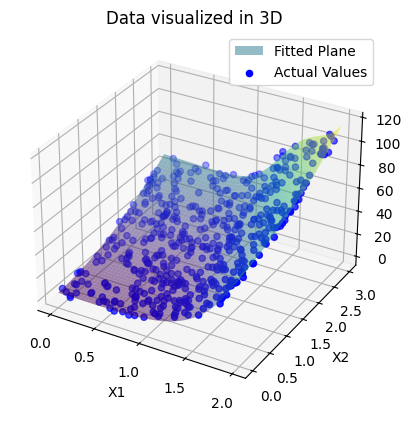

In [60]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

X1_grid, X2_grid = np.meshgrid(np.linspace(min(X1), max(X1), 100), np.linspace(min(X2), max(X2), 100))
y_pred_plane = 2 * X1_grid**5 + 4 * X2_grid**2 - X1_grid*X2_grid + 10*X2_grid*(np.sin(X1_grid)**13.5) + 3*X2_grid + 5

ax.plot_surface(X1_grid, X2_grid, y_pred_plane, alpha=0.5, cmap='viridis', label='Fitted Plane')
ax.scatter(X1, X2, y, c='blue', marker='o', label='Actual Values')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title('Data visualized in 3D')

plt.legend()
plt.show()

Looks pretty complicated! Let's see if our neural network can learn to predict the y values given the features (Xs).
First, split `X` and `y` into training and validation cohorts.

In [61]:
X_train, X_val, Y_train, Y_val = train_test_split(X, y, test_size=0.2, random_state=8)

Next, initialize your Neural Network class in regression mode. Experiment with different sizes and various combinations of optimizers and activation functions (remember to use a very small learning rate with ReLU) until you get the best results.

Note: You are required to show at least three of the models' results that you get.

  0%|          | 0/60 [00:00<?, ?it/s]

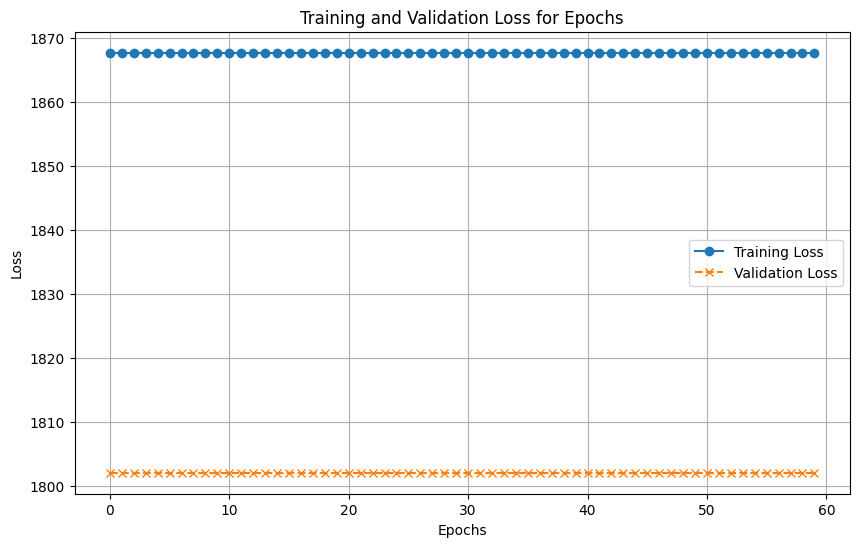

In [62]:
#exp1
network_size = [2, 50, 50, 1]
nn = NeuralNetwork(network_size, mode='regression', activation='relu', optimizer='minibatch', batch_size=32)


history, val_hist = nn.fit(X_train, Y_train, X_val, Y_val, epochs=60, lr=0.01)

plot_losses(history, val_hist)

  0%|          | 0/60 [00:00<?, ?it/s]

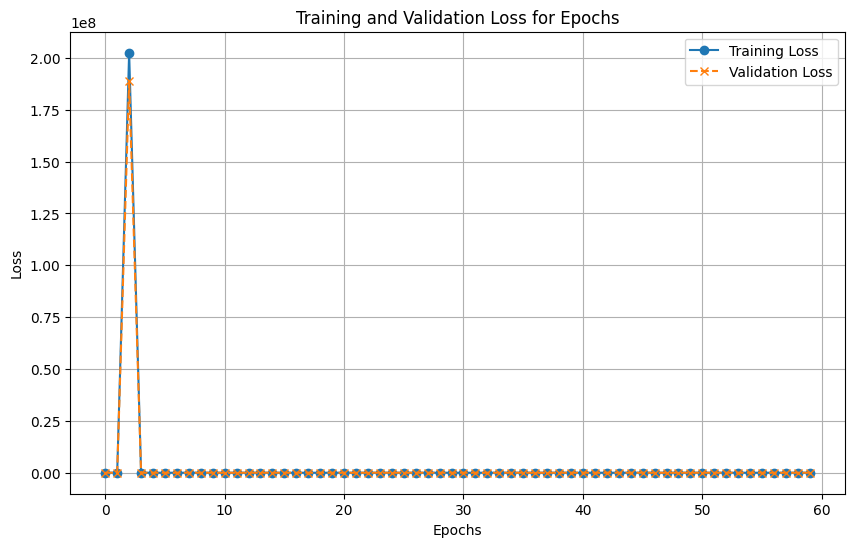

In [63]:
#exp2
network_size = [2, 20, 20, 1]
nn = NeuralNetwork(network_size, mode='regression', activation='relu', optimizer='fullbatch', batch_size=32)


history, val_hist = nn.fit(X_train, Y_train, X_val, Y_val, epochs=60, lr=0.01)

plot_losses(history, val_hist)

  0%|          | 0/60 [00:00<?, ?it/s]

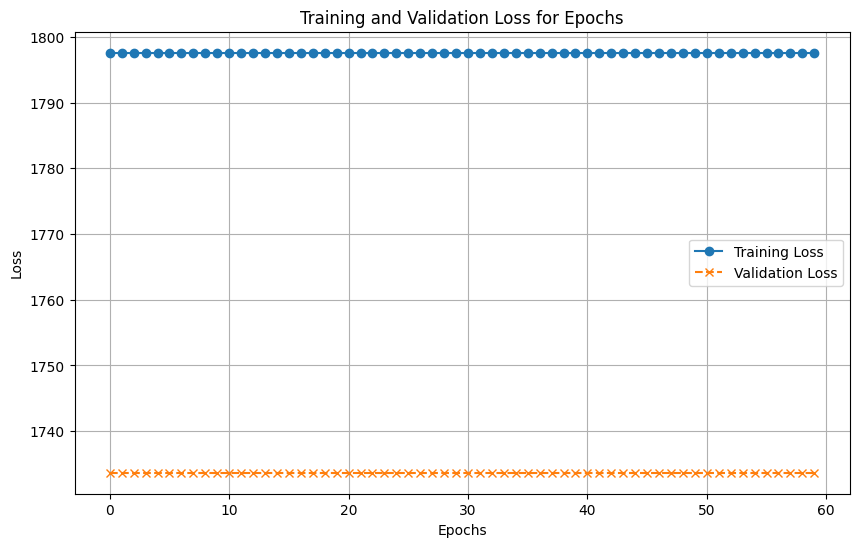

In [64]:
#exp3
network_size = [2, 10, 10, 1]
nn = NeuralNetwork(network_size, mode='regression', activation='sigmoid', optimizer='sgd', batch_size=32)


history, val_hist = nn.fit(X_train, Y_train, X_val, Y_val, epochs=60, lr=0.01)

plot_losses(history, val_hist)

Let's see how well the model's predictions match to the ground truth values.

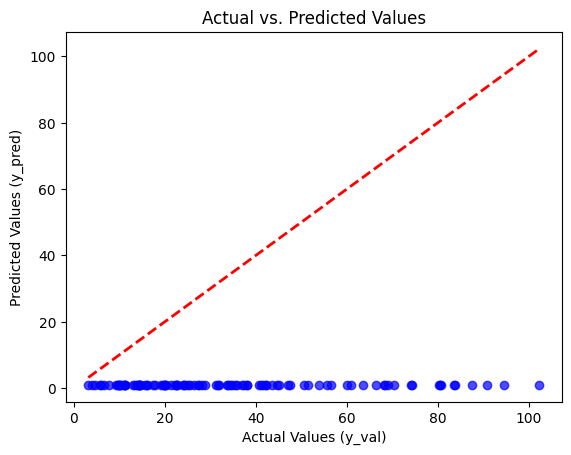

In [65]:
y_pred = nn.predict(X_val)

plt.scatter(Y_val, y_pred, c='blue', alpha=0.7)
plt.plot([min(Y_val), max(Y_val)], [min(Y_val), max(Y_val)], '--', color='red', linewidth=2)  # Diagonal line for reference
plt.xlabel('Actual Values (y_val)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values')
plt.show()